# Parts 8 & 9 — Database & Retrieval · Production, Monitoring & Architecture
## UTD-MHAD Multimodal Human Activity Recognition

This notebook contains the theoretical and architectural analysis for the final two parts of the project:

- **Part 8**: Database & Retrieval Strategy — leveraging historical embeddings for Few-Shot Learning and similarity search.
- **Part 9**: Production, Monitoring & Architecture — metrics, drift detection, logging, retraining triggers, and an end-to-end system diagram.

These parts build directly on the safety mechanisms developed in Parts 6 (Conformal Prediction) and 7 (VAE-based OOD Detection).

---
# Part 8: Database & Retrieval Strategy

Once a multimodal HAR system is deployed, it accumulates a growing corpus of **labeled past events** — fusion embeddings paired with ground-truth or human-verified action labels. This section examines how to exploit that corpus without retraining from scratch.

## 8.1 Leveraging a Labeled Event Database

The embedding produced by the fusion encoder (video + inertial trunk, pre-classifier) is a compact, semantically rich representation of an activity window. Storing these embeddings in a vector database unlocks two high-value capabilities:

### Few-Shot Learning via Prototypical Retrieval
- For a **new action class** with only a handful of labeled examples, compute the class prototype (mean embedding over the support set).
- At inference time, classify by nearest-prototype distance — no gradient updates required.
- The stored gallery acts as the support set, growing richer with every verified sample.
- This is the backbone of **Prototypical Networks** and **Matching Networks**: the model architecture is frozen; only the gallery changes.

### Reference Gallery for Similarity Search
- Each incoming sample is compared (cosine or L2 distance) against the gallery to retrieve the *k* most similar historical events.
- The retrieved labels provide an **evidence-weighted soft prediction**: a transparent, interpretable result alongside the classifier output.
- Particularly valuable when the classifier's confidence is borderline (CP prediction set size > 1): retrieval can act as a tie-breaker.
- A gallery with diverse, well-curated embeddings also serves as a **ground-truth anchor** for detecting embedding drift over time (§9.2).

## 8.2 Retrieval vs. Fine-tuning — Comparative Analysis

| Dimension | **Retrieval (RAG-style)** | **Fine-tuning** |
|---|---|---|
| **Core mechanism** | Nearest-neighbour search over a frozen embedding space | Gradient updates to encoder and/or classifier weights |
| **Data requirement** | Works with as few as 1–5 labelled examples (few-shot) | Typically requires 50–500+ labelled examples per new class |
| **Cold-start** | Excellent — add a new class by inserting one prototype | Poor — requires a dedicated fine-tuning run |
| **Scalability** | Gallery grows linearly; indexing (FAISS/ScaNN) keeps search O(log n) | Cost grows with dataset size; diminishing returns with scale |
| **Latency** | Adds a kNN lookup (~1–5 ms for 10k gallery with FAISS) | No added inference latency after fine-tuning is done |
| **Accuracy ceiling** | Bounded by embedding quality; poor if embeddings are noisy | Can reach higher accuracy on the target distribution |
| **Catastrophic forgetting** | None — model weights are frozen | High risk unless using EWC, LoRA, or replay buffers |
| **Transparency** | High — retrieved neighbours are human-inspectable evidence | Low — weight changes are opaque |
| **Infrastructure cost** | Vector DB + indexing pipeline | GPU/TPU compute, experiment tracking, regression testing |
| **Deployment risk** | Low — rollback is deleting gallery entries | High — a bad fine-tune can silently degrade all classes |

### Decision Criteria for Action Recognition

**Prefer Retrieval when:**
- A new action class appears in production with fewer than ~30 labelled samples.
- The deployment environment changes (new sensor placement, new subject population) but the action ontology is stable.
- Low operational risk tolerance — changes must be explainable and instantly reversible.
- Low latency budget exists for the kNN step and the embedding encoder is already high quality.

**Prefer Fine-tuning when:**
- A large labelled corpus (hundreds of samples per class) is available for the new distribution.
- The new domain differs substantially from the pre-training domain (e.g., different sensor modality, body placement, or activity taxonomy) — embeddings may not transfer well.
- Throughput/latency requirements prohibit any gallery lookup overhead.
- Periodic scheduled retrains are already part of the operational workflow (§9.4).

**Hybrid approach (recommended for production HAR):**

Use retrieval as an **online, zero-downtime mechanism** for cold-start and new-class onboarding. Accumulate verified labels into a replay buffer and trigger a scheduled fine-tune (with EWC regularisation to protect old classes) once the buffer exceeds a volume threshold. Post fine-tune, the gallery is regenerated from the new encoder and the cycle restarts.

---
# Part 9: Production, Monitoring & Architecture

Deploying a multimodal model is not the end of the engineering effort — it is the beginning. This section specifies the monitoring framework, drift-detection methodology, operational playbook, and system architecture needed to maintain reliability under real-world conditions.

## 9.1 Critical Monitoring Metrics

### Latency & Throughput
| Metric | Target | Alert Threshold |
|---|---|---|
| End-to-end inference latency (p50) | < 80 ms | > 150 ms |
| End-to-end inference latency (p99) | < 200 ms | > 500 ms |
| Video preprocessing latency | < 30 ms | > 80 ms |
| Inertial preprocessing latency | < 5 ms | > 20 ms |
| Fusion forward-pass latency | < 20 ms | > 50 ms |
| kNN gallery lookup (if retrieval enabled) | < 5 ms | > 20 ms |

### Reliability & Availability
- **Modality-specific uptime**: Track camera feed availability and IMU stream uptime separately. A dropped modality should trigger graceful degradation to the single-modality branch, not a service crash.
- **Prediction throughput**: Requests served per second; drop indicates upstream bottleneck.
- **Error rate per modality**: Silent sensor failures (flat-lined IMU, frozen video frame) must be caught before they enter the fusion encoder.

### Model Quality
- **Rolling accuracy / macro-F1** on human-verified samples (sampled at ~5% of traffic).
- **Prediction Confidence Distribution**: Track the histogram of softmax max-probability. A shift toward lower confidence signals distributional drift before accuracy degrades.
- **CP prediction set size distribution**: Track the proportion of singleton vs. multi-element prediction sets. A rising multi-element rate indicates the model is becoming less decisive.
- **OOD Rate**: Fraction of requests flagged by the VAE reconstruction-error gate. Spikes indicate a new environmental condition or sensor failure.
- **Per-class precision/recall** (computed on verified samples): catches silent class-level degradation invisible in aggregate metrics.

### Safety Gates (from Parts 6 & 7)
- **Conformal coverage rate**: Empirical coverage on a held-out calibration stream should remain at the target level (e.g., 90%). Significant deviation means the calibration set is stale.
- **VAE ELBO / reconstruction MSE**: Track the running mean and variance. A rising mean = systematic input shift.

## 9.2 Drift Detection

### Data Drift — Feature Distribution Shifts

Data drift occurs when the statistical properties of the inputs change while the underlying task remains the same (e.g., a sensor is repositioned, lighting conditions change, a new subject population is introduced).

**Detection methods:**

| Method | What it monitors | Implementation |
|---|---|---|
| **Population Stability Index (PSI)** | Feature marginal distributions (binned histograms vs. reference) | Compute per-feature; PSI > 0.2 = significant drift |
| **Maximum Mean Discrepancy (MMD)** | Joint embedding distribution vs. a reference gallery window | Kernel two-sample test; effective in high-dimensional spaces |
| **KL / JS Divergence** | Softmax output distribution vs. calibration-time distribution | Lightweight; catches label-space shifts even before accuracy drops |
| **VAE Reconstruction Error Trend** | Input-level raw feature quality | Already instrumented in Part 7; a rising mean MSE = data drift |
| **Univariate statistical tests** | Individual sensor channels (Kolmogorov-Smirnov, CUSUM) | Useful for IMU channel-level anomaly detection |

### Concept Drift — Shifts in the Input-Label Relationship

Concept drift occurs when the statistical relationship between inputs and labels changes (e.g., the same gesture now means a different activity, or population physiology changes).

**Detection methods:**

| Method | Mechanism |
|---|---|
| **Error-rate monitoring on labelled stream** | Rolling accuracy on human-verified samples; a sustained drop while data drift metrics are stable implies concept drift |
| **ADWIN (Adaptive Windowing)** | Statistical test over error-rate time series; automatically identifies the change-point with variable window size |
| **Embeddings vs. labels consistency** | Track inter-class centroid distances in embedding space; collapsing centroids imply class confusion (concept drift) |
| **Shadow model comparison** | Run a freshly retrained model in shadow mode; diverging predictions vs. the production model signal that the old model has become stale |

## 9.3 Logging Strategy

### What to Log (per inference request)

| Log field | Purpose |
|---|---|
| `request_id`, `timestamp`, `subject_id` | Audit trail, GDPR compliance |
| Raw sensor window checksum (not raw data) | Integrity verification without storing PII |
| Preprocessing output statistics (mean, std per channel) | Detect silent sensor failures |
| Fusion embedding vector | Enables offline drift analysis and gallery refresh |
| Softmax probability vector (all classes) | Full confidence profile, not just argmax |
| CP prediction set and calibrated threshold $\hat{q}$ | Reproducing the uncertainty estimate offline |
| VAE reconstruction MSE (per modality and fused) | OOD forensics |
| Final prediction label (or "abstain" / "OOD") | Outcome for accuracy monitoring |
| Human-verified label (async, when available) | Ground truth for retraining pipeline |
| Latency breakdown (preprocessing / fusion / gate / lookup) | Performance profiling |
| Active model version + calibration set hash | Reproducibility |

### Log Storage Architecture
- **Hot tier** (last 7 days): fast storage (Redis or Kafka stream) for real-time dashboards and immediate alerting.
- **Warm tier** (last 90 days): columnar store (Parquet on S3/GCS) for drift analysis queries.
- **Cold tier** (archive): compressed long-term storage for regulatory compliance and large-batch retraining runs.

## 9.4 Retraining Triggers

Retraining should be **event-driven** (immediate) or **scheduled** (periodic), not ad-hoc.

### Immediate Triggers (alert + auto-queue retraining job)
| Trigger | Threshold | Action |
|---|---|---|
| Rolling macro-F1 on verified samples | Drops > 5 pp below deployment baseline over 48 h | Automatic retraining job queued |
| Per-class recall on any class | Drops below 0.60 for > 24 h | Same |
| OOD rate | Exceeds 25% of requests for > 2 h | Investigate + queue if OOD samples are labellable |
| CP multi-element set rate | Exceeds 40% (target is ≤ 10%) | Recalibrate conformal threshold immediately; retrain if persists |
| Data drift PSI | Any feature PSI > 0.25 sustained over 6 h | Trigger preprocessing audit; queue retrain if structural |

### Scheduled Triggers (time-based)
- **Weekly**: Recalibrate the conformal quantile $\hat{q}$ on a fresh rolling calibration split.
- **Monthly**: Full model retrain on the accumulated replay buffer (new verified samples + stratified sample of historical data).
- **Quarterly**: Architecture review — benchmark current model against a freshly trained challenger; promote if it wins on a held-out evaluation set.

### Retraining Safeguards
- **Regression gate**: New model must match or beat production model on a frozen held-out test set before promotion.
- **Shadow deployment**: New model runs in parallel for 24 h before cut-over; prediction divergence rate monitored.
- **Rollback policy**: Previous model weights and calibration set retained for 30 days.

## 9.5 End-to-End System Architecture

The diagram below captures the full production pipeline. The key design principle: **no prediction leaves the system without passing through two explicit safety filters** — the VAE-based OOD gate (Part 7) and the Conformal Prediction gate (Part 6). These are load-bearing components of the inference path, not optional post-processors.

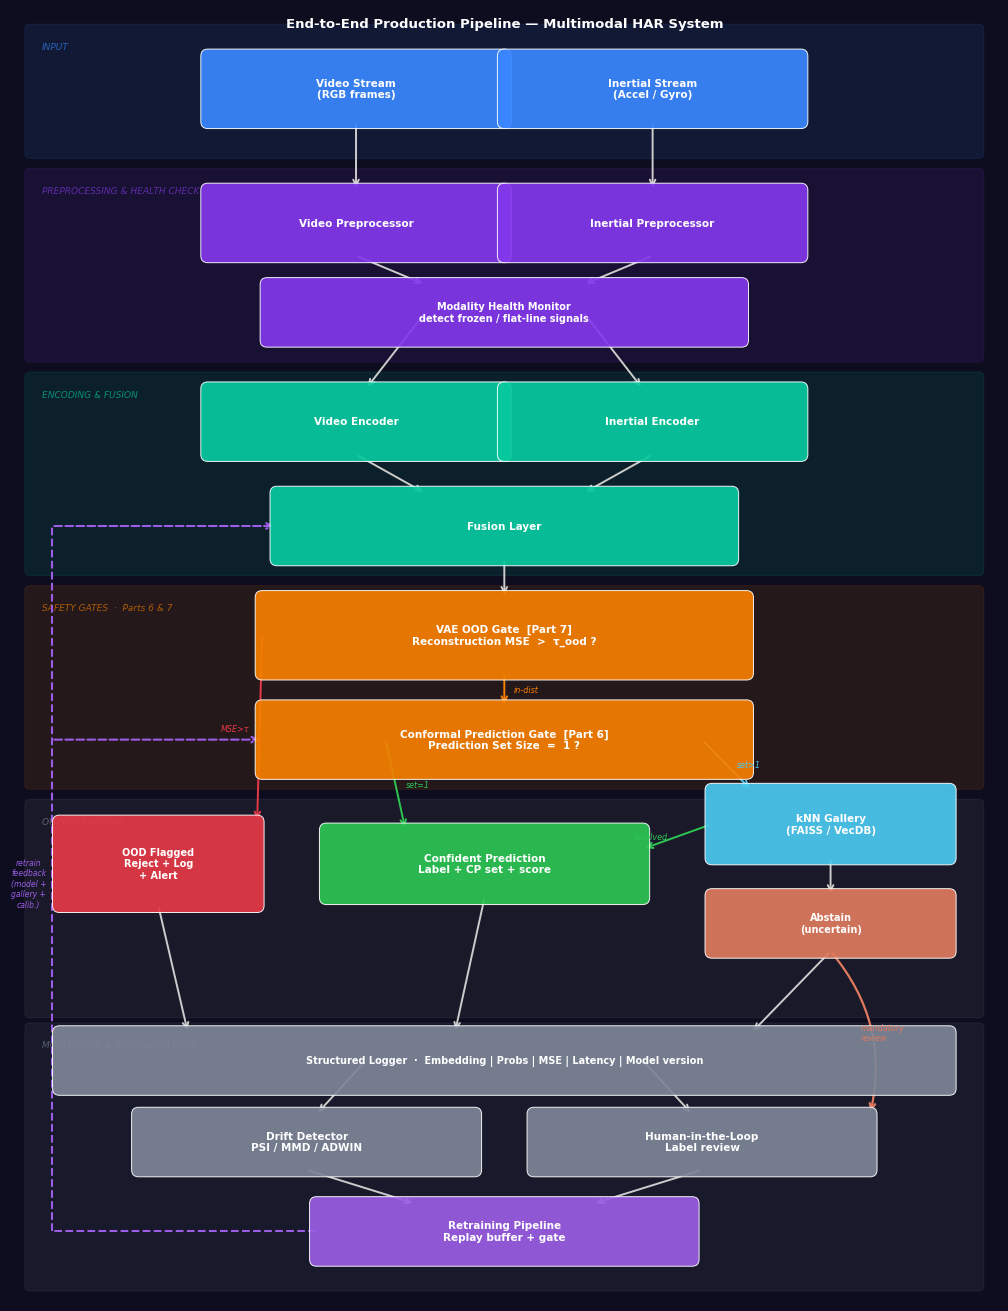

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 13))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13.0)
ax.set_facecolor('#0d0d1f')
fig.patch.set_facecolor('#0d0d1f')
ax.axis('off')

C = dict(
    inp='#3A86FF', prep='#8338EC', enc='#06C99F',
    sfty='#F77F00', ood='#E63946', pred='#2DC653',
    retr='#4CC9F0', abst='#E07A5F', mon='#7D8597', ret='#9B5DE5',
)


def box(ax, cx, cy, hw, hh, text, col, fs=7.5):
    ax.add_patch(FancyBboxPatch(
        (cx - hw, cy - hh), 2 * hw, 2 * hh,
        boxstyle='round,pad=0.07', facecolor=col,
        edgecolor='white', linewidth=0.7, alpha=0.92, zorder=3))
    ax.text(cx, cy, text, ha='center', va='center',
            fontsize=fs, color='white', fontweight='bold',
            zorder=4, multialignment='center')


def arr(ax, x1, y1, x2, y2, lbl='', col='#cccccc', lw=1.4, rad=0.0):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=col, lw=lw,
                                connectionstyle=f'arc3,rad={rad}'), zorder=2)
    if lbl:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        dx = 0.10 if x2 >= x1 else -0.10
        ax.text(mx + dx, my, lbl, fontsize=5.8, color=col, style='italic',
                va='center', ha='left' if dx > 0 else 'right')


def sect(ax, x, y, w, h, label, col):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h, boxstyle='round,pad=0.05',
        facecolor=col, edgecolor=col,
        linewidth=0.8, alpha=0.10, zorder=1))
    ax.text(x + 0.12, y + h - 0.20, label, fontsize=6.5,
            color=col, alpha=0.65, style='italic', zorder=2)


# ── section bands ────────────────────────────────────────────────────────
sect(ax, 0.20, 11.55, 9.60, 1.25, 'INPUT', C['inp'])
sect(ax, 0.20,  9.50, 9.60, 1.85, 'PREPROCESSING & HEALTH CHECK', C['prep'])
sect(ax, 0.20,  7.35, 9.60, 1.95, 'ENCODING & FUSION', C['enc'])
sect(ax, 0.20,  5.20, 9.60, 1.95, 'SAFETY GATES  ·  Parts 6 & 7', C['sfty'])
sect(ax, 0.20,  2.90, 9.60, 2.10, 'OUTPUT ROUTING', '#888888')
sect(ax, 0.20,  0.15, 9.60, 2.60, 'MONITORING & RETRAINING LOOP', C['mon'])

# ── INPUT ────────────────────────────────────────────────────────────────
box(ax, 3.5, 12.20, 1.50, 0.33, 'Video Stream\n(RGB frames)', C['inp'])
box(ax, 6.5, 12.20, 1.50, 0.33, 'Inertial Stream\n(Accel / Gyro)', C['inp'])

# ── PREPROCESSING ────────────────────────────────────────────────────────
box(ax, 3.5, 10.85, 1.50, 0.33, 'Video Preprocessor', C['prep'])
box(ax, 6.5, 10.85, 1.50, 0.33, 'Inertial Preprocessor', C['prep'])
box(ax, 5.0,  9.95, 2.40, 0.28, 'Modality Health Monitor\ndetect frozen / flat-line signals', C['prep'], fs=7.0)

# ── ENCODING & FUSION ────────────────────────────────────────────────────
box(ax, 3.5, 8.85, 1.50, 0.33, 'Video Encoder', C['enc'])
box(ax, 6.5, 8.85, 1.50, 0.33, 'Inertial Encoder', C['enc'])
box(ax, 5.0, 7.80, 2.30, 0.33, 'Fusion Layer', C['enc'])

# ── SAFETY GATES ─────────────────────────────────────────────────────────
box(ax, 5.0, 6.70, 2.45, 0.38, 'VAE OOD Gate  [Part 7]\nReconstruction MSE  >  \u03c4_ood ?', C['sfty'])
box(ax, 5.0, 5.65, 2.45, 0.33, 'Conformal Prediction Gate  [Part 6]\nPrediction Set Size  =  1 ?', C['sfty'])

# ── OUTPUT ROUTING ───────────────────────────────────────────────────────
box(ax, 1.50, 4.40, 1.00, 0.42, 'OOD Flagged\nReject + Log\n+ Alert', C['ood'], fs=7.0)
box(ax, 4.80, 4.40, 1.60, 0.34, 'Confident Prediction\nLabel + CP set + score', C['pred'])
box(ax, 8.30, 4.80, 1.20, 0.34, 'kNN Gallery\n(FAISS / VecDB)', C['retr'])
box(ax, 8.30, 3.80, 1.20, 0.28, 'Abstain\n(uncertain)', C['abst'], fs=7.0)

# ── MONITORING ───────────────────────────────────────────────────────────
box(ax, 5.0, 2.42, 4.50, 0.28,
    'Structured Logger  ·  Embedding | Probs | MSE | Latency | Model version',
    C['mon'], fs=7.0)
box(ax, 3.0, 1.60, 1.70, 0.28, 'Drift Detector\nPSI / MMD / ADWIN', C['mon'])
box(ax, 7.0, 1.60, 1.70, 0.28, 'Human-in-the-Loop\nLabel review', C['mon'])
box(ax, 5.0, 0.70, 1.90, 0.28, 'Retraining Pipeline\nReplay buffer + gate', C['ret'])

# ── ARROWS: main flow ────────────────────────────────────────────────────
arr(ax, 3.5, 11.87, 3.5, 11.18)                          # Video in → prep
arr(ax, 6.5, 11.87, 6.5, 11.18)                          # Inertial in → prep
arr(ax, 3.5, 10.52, 4.20, 10.23)                         # Vid prep → health
arr(ax, 6.5, 10.52, 5.80, 10.23)                         # Ine prep → health
arr(ax, 4.20,  9.95, 3.60,  9.18)                        # Health → vid enc
arr(ax, 5.80,  9.95, 6.40,  9.18)                        # Health → ine enc
arr(ax, 3.5,  8.52, 4.20,  8.13)                         # Vid enc → fusion
arr(ax, 6.5,  8.52, 5.80,  8.13)                         # Ine enc → fusion
arr(ax, 5.0,  7.47, 5.0,   7.08)                         # Fusion → VAE
arr(ax, 5.0,  6.32, 5.0,   5.98, 'in-dist', C['sfty'])   # VAE → CP
arr(ax, 2.55, 6.70, 2.50,  4.82, 'MSE>\u03c4', C['ood']) # VAE → OOD flag
arr(ax, 3.80, 5.65, 4.00,  4.74, 'set=1', C['pred'])     # CP → confident
arr(ax, 7.00, 5.65, 7.50,  5.14, 'set>1', C['retr'])     # CP → kNN
arr(ax, 7.10, 4.80, 6.40,  4.55, 'resolved', C['pred'])  # kNN → confident
arr(ax, 8.30, 4.46, 8.30,  4.08)                         # kNN → abstain
arr(ax, 1.50, 3.98, 1.80,  2.70)                         # OOD → logger
arr(ax, 4.80, 4.06, 4.50,  2.70)                         # Confident → logger
arr(ax, 8.30, 3.52, 7.50,  2.70)                         # Abstain → logger
# Abstain → Human direct mandatory-review path (curved, bypasses drift detector)
arr(ax, 8.30, 3.52, 8.70,  1.88, 'mandatory\nreview', C['abst'], lw=1.6, rad=-0.25)
arr(ax, 3.60, 2.42, 3.10,  1.88)                         # Logger → drift
arr(ax, 6.40, 2.42, 6.90,  1.88)                         # Logger → human
arr(ax, 3.00, 1.32, 4.10,  0.98)                         # Drift → retrain
arr(ax, 7.00, 1.32, 5.90,  0.98)                         # Human → retrain

# ── RETRAIN FEEDBACK (dashed, left margin) ───────────────────────────────
lc = C['ret']
ax.plot([3.10, 0.42], [0.70, 0.70], color=lc, lw=1.5, ls='--', zorder=2)
ax.plot([0.42, 0.42], [0.70, 7.80], color=lc, lw=1.5, ls='--', zorder=2)
# → Fusion
ax.annotate('', xy=(2.70, 7.80), xytext=(0.42, 7.80),
            arrowprops=dict(arrowstyle='->', color=lc, lw=1.5, linestyle='dashed'),
            zorder=2)
# → CP calibration
ax.annotate('', xy=(2.55, 5.65), xytext=(0.42, 5.65),
            arrowprops=dict(arrowstyle='->', color=lc, lw=1.5, linestyle='dashed'),
            zorder=2)
ax.text(0.19, 4.20, 'retrain\nfeedback\n(model +\ngallery +\ncalib.)',
        fontsize=5.5, color=lc, ha='center', va='center', style='italic', zorder=5)

# ── TITLE ────────────────────────────────────────────────────────────────
ax.text(5.0, 12.92,
        'End-to-End Production Pipeline — Multimodal HAR System',
        ha='center', va='top', fontsize=9.5, fontweight='bold', color='white')

plt.tight_layout(pad=0.3)
plt.savefig('../data/pipeline_architecture.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d1f')
plt.show()

### Key Architectural Decisions

1. **VAE gate fires first** — operates directly on the fusion embedding before the classifier head runs. Cheap early rejection of OOD inputs prevents the classifier from producing confident-looking predictions on garbage inputs.

2. **Conformal Prediction gate is second** — uses the calibrated non-conformity score to emit a coverage-guaranteed prediction set. A singleton set means high confidence and passes immediately. A multi-element set activates the retrieval branch instead of an outright refusal, maximising utility for in-distribution but ambiguous samples.

3. **kNN gallery as a tie-breaker** — retrieval only activates on uncertain CP outputs (set size > 1). The hot path (singleton CP output) has no gallery overhead; the gallery only incurs cost when the model itself is uncertain.

4. **Feedback loop is closed through the logger** — every request regardless of outcome feeds the drift monitor and the human-review queue. The retraining pipeline consumes from this queue and updates model weights, the gallery, and the conformal quantile $\hat{q}$ together, keeping all three in sync.

5. **VAE and CP recalibrate jointly after retraining** — the dashed feedback arrow touches both the Fusion layer (new weights → new embeddings) and the CP Gate (new calibration set → updated $\hat{q}$). Omitting the CP recalibration step after retraining silently degrades coverage guarantees even if model accuracy improves.

6. **Abstain is a labelling request, not a failure** — when the CP gate emits a multi-element set *and* the kNN gallery cannot resolve the ambiguity (all top-k neighbours belong to different classes with no clear plurality), the system emits `Abstain` instead of guessing. This outcome takes a **direct path to the Human-in-the-Loop queue**, bypassing the drift detector, because the sample is already known to be ambiguous and requires an immediate label — not a statistical test. Once labelled, the verified sample enters the replay buffer and is used both to expand the gallery prototype for that class and to contribute to the next scheduled fine-tune. Human review is therefore triggered by three distinct conditions, each with a different urgency:

| Trigger | Path | Urgency | Purpose |
|---|---|---|---|
| **Abstain** (kNN inconclusive) | Direct → Human queue | Immediate | Provide a missing label; expand gallery |
| **OOD Flagged** (VAE gate) | Logger → Human queue | High | Determine if it is a new class, sensor fault, or adversarial input |
| **Drift detected** (Drift Detector) | Drift Detector → Human queue | Scheduled | Audit and relabel a stratified sample to confirm concept drift |

7. **Retraining Pipeline is a gated promotion process, not a raw retrain** — it consumes the replay buffer (human-verified labels from Abstain + OOD paths) combined with a stratified sample of historical data to prevent catastrophic forgetting. Before any new weights reach production, they must pass a **regression gate**: the challenger model is evaluated on a frozen held-out test set and must match or exceed the current production model. On promotion, the pipeline pushes three artefacts simultaneously — updated model weights to the Fusion Layer, refreshed gallery embeddings computed under the new encoder, and a recalculated conformal quantile $\hat{q}$ from a fresh calibration split. Promoting weights without regenerating the gallery or recalibrating CP breaks the consistency of all downstream safety guarantees.